# MVTec AD - four anomaly detectors, and where each number comes from

**Arkon Manufacturing AI | Module: CV Anomaly | Department: Component Inspection**

Notebook 01 measured what the four categories contain and notebook 02 settled
the split, the input and the augmentation question. This one builds the module:
four memory banks of sound parts, one per category, and a score that says how
far a new part sits from them. It is the fifth model in the Arkon platform and
the third to publish through the visual inspection domain.

**No part of this module is trained.** The backbone is a frozen ImageNet
ResNet-18 and nothing is fitted to MVTec at all: what the module holds is a
collection of feature vectors taken from sound parts, and what it computes is a
distance. That removes a whole class of question this project has spent two
modules on, and it introduces a different one. There is no training loss to
watch, no epoch to select and no seed to blame, so the run-to-run instability
that made casting's operating point unusable cannot arise the same way here.
Section 12 measures whether it arises at all.

Four things this notebook has to get right. Every number says which set produced
it. The threshold is stated as a false-alarm budget on sound parts rather than
searched for on the scores, which is the direct lesson of the casting module.
The size of the memory bank is chosen without using a single defect, because a
criterion that reads defect labels is a criterion read off the only labelled
defects this dataset has. And the one place where that is not possible is
labelled as such in section 8 rather than left implied.

In [1]:
import sys
from pathlib import Path

# notebooks/ holds the shared helpers; this notebook sits two levels below it
_nb_root = Path('../..').resolve()
if str(_nb_root) not in sys.path:
    sys.path.insert(0, str(_nb_root))

from utils.arkon_utils import get_mlflow_uri, save_figure

print('arkon_utils loaded')

arkon_utils loaded


## 1. Imports and configuration

Nothing is imported from a training script, because this module has none: what
these three notebooks write is the first version of it that exists.

In [2]:
import json
import platform
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from PIL import Image
from sklearn.metrics import roc_auc_score, roc_curve
from torchvision import models, transforms
from torchvision.transforms.functional import gaussian_blur

plt.style.use('seaborn-v0_8-darkgrid')

ASSETS = 'cv'
REPO_ROOT = Path('../../..').resolve()
RAW_DIR = Path('../../../data/05_mvtec/raw')
PROC_DIR = Path('../../../data/05_mvtec/processed')
MODEL_DIR = Path('../../../models/checkpoints/mvtec')
CATEGORIES = sorted(d.name for d in RAW_DIR.iterdir() if d.is_dir())

SEED = 42
CALIBRATION_FRACTION = 0.30      # notebook 02 settled this cut
IMAGE_SIZE = 320                 # notebook 02 section 5: a defect fills a whole layer2 cell here
ALTERNATIVE_SIZE = 224
LAYERS = ('layer2', 'layer3')    # notebook 02 section 5 measured why
LAYER_STRIDE = 8                 # layer2 output stride: the grid side is IMAGE_SIZE // 8
BANK_BUDGETS = (0.005, 0.01, 0.02, 0.05)
BANK_TOLERANCE = 0.02            # how far the reduced bank may move a sound part's score
FALSE_ALARM_BUDGET = 0.05        # share of sound parts the threshold is allowed to flag
BATCH_SIZE = 16
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

MODEL_VERSION = 'mvtec_patchcore_v1'
EXPERIMENT_NAME = 'arkon-cv-mvtec'

GRID = IMAGE_SIZE // LAYER_STRIDE


def budget_label(fraction):
    """A budget of 0.005 is 0.5 per cent, and ':.0%' rounds that to 0 per cent, which
    labels a real bank as an empty one. Keep a decimal only where one is needed."""
    return f'{fraction * 100:g}%'
SMOOTHING_SIGMA = round(4 * IMAGE_SIZE / 224)   # 4 pixels at 224, scaled to the input in use
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(SEED)
pd.set_option('display.width', 130)
print(f'python  {sys.version.split()[0]}   torch {torch.__version__}')
print(f'device  {DEVICE}'
      + (f'  {torch.cuda.get_device_name(0)}' if DEVICE.type == 'cuda' else ''))
print(f'machine {platform.system()} {platform.machine()}')
print(f'input   {IMAGE_SIZE}, grid {GRID}x{GRID} = {GRID ** 2} patches per image')

python  3.12.10   torch 2.6.0+cu124
device  cuda  NVIDIA GeForce RTX 3070 Laptop GPU
machine Windows AMD64
input   320, grid 40x40 = 1600 patches per image


## 2. There is no reference run to read

The other four modules open a metrics file first and check the notebook against
what the deployed model recorded. This one cannot, and the cell states that
rather than assuming it, because a missing reference and an unread one look the
same from inside a notebook.

In [3]:
MODEL_DIR.mkdir(parents=True, exist_ok=True)
existing = sorted(p.name for p in MODEL_DIR.iterdir())
reference = MODEL_DIR / 'mvtec_cv_meta.json'
card = Path('../../../docs/Model_Card_MVTec_Anomaly.md')
adapter = Path('../../../events/make_events_mvtec.py')
print(f'{MODEL_DIR.as_posix()} holds: {existing if existing else "nothing"}')
print(f'metrics file present : {reference.is_file()}')
print(f'model card present   : {card.is_file()}')
print(f'event adapter        : {adapter.is_file()}')
print()
if reference.is_file():
    print('A metrics file from an earlier run is present and this run overwrites it. The')
    print('model card cites the run stored in that file, so a card read beside a fresh run')
    print('of this notebook is a card read beside different numbers.')
else:
    print('So there is nothing to reproduce and nothing to compare against. What this')
    print('notebook writes becomes the reference the next run is checked against, and')
    print('section 12 asks the only reproduction question that can be asked today:')
    print('whether this code, run twice in one session, agrees with itself.')

../../../models/checkpoints/mvtec holds: ['mvtec_cv_meta.json', 'mvtec_patchcore_v1_grid_bank.npy', 'mvtec_patchcore_v1_metal_nut_bank.npy', 'mvtec_patchcore_v1_screw_bank.npy', 'mvtec_patchcore_v1_transistor_bank.npy']
metrics file present : True
model card present   : True
event adapter        : True

A metrics file from an earlier run is present and this run overwrites it. The
model card cites the run stored in that file, so a card read beside a fresh run
of this notebook is a card read beside different numbers.


## 3. The split, and the three sets every number below names

Notebook 02 measured this cut; this cell rebuilds it from the same seed so the
notebook stands alone. Three sets per category, and each one has exactly one
job.

- **bank**, 70 per cent of the sound training parts. This is the model. Nothing
  else is fitted.
- **calibration**, the other 30 per cent. Sound parts the bank does not hold. It
  sets the threshold in section 9 and the size of the bank in section 5, and it
  contains no defect, which is what makes both choices safe to make on it.
- **test**, the folder the dataset ships as `test/`, sound and defective mixed.
  Scored once, in section 10.

In [4]:
rng = np.random.default_rng(SEED)
split = {}
rows = []
for category in CATEGORIES:
    good = sorted((RAW_DIR / category / 'train' / 'good').glob('*.png'))
    order = rng.permutation(len(good))
    cut = int(round(len(good) * CALIBRATION_FRACTION))
    test_paths, test_labels, test_defects = [], [], []
    for folder in sorted(d for d in (RAW_DIR / category / 'test').iterdir() if d.is_dir()):
        for path in sorted(folder.glob('*.png')):
            test_paths.append(path)
            test_labels.append(0 if folder.name == 'good' else 1)
            test_defects.append(folder.name)
    split[category] = {
        'bank': [good[i] for i in sorted(order[cut:])],
        'calibration': [good[i] for i in sorted(order[:cut])],
        'all_good': good,
        'test': test_paths,
        'test_label': np.array(test_labels),
        'test_defect': test_defects,
    }
    rows.append({'category': category, 'bank': len(split[category]['bank']),
                 'calibration': cut, 'test': len(test_paths),
                 'test_defective': int(sum(test_labels))})

composition = pd.DataFrame(rows).set_index('category')
print(composition.to_string())
print()
print(f'The cut is {1 - CALIBRATION_FRACTION:.0%}/{CALIBRATION_FRACTION:.0%} at seed {SEED}, '
      f'the same draw notebook 02 measured.')

            bank  calibration  test  test_defective
category                                           
grid         185           79    78              57
metal_nut    154           66   115              93
screw        224           96   160             119
transistor   149           64   100              40

The cut is 70%/30% at seed 42, the same draw notebook 02 measured.


## 4. The representation, and the two ways to reduce it to a score

A frozen ResNet-18. `layer2` and `layer3` are read through forward hooks, each
smoothed with a 3 by 3 average so a cell carries its neighbourhood, `layer3` is
resampled onto `layer2`'s grid, and the two are concatenated. That gives one
384-dimensional vector per grid cell.

The same hooks also give the alternative the skeleton in this folder implements:
`layer4` averaged over the whole frame, one 512-dimensional vector per image.
Both are built here so section 7 can measure them against each other on the same
images.

In [5]:
backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1).to(DEVICE).eval()
taps = {}
for name in ('layer1', 'layer2', 'layer3', 'layer4'):
    getattr(backbone, name).register_forward_hook(
        lambda module, inputs, output, key=name: taps.__setitem__(key, output))

transform_cache = {}


def release():
    """Hand device memory back between stages that each hold a whole feature set."""
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()


def load_batch(paths, size):
    """Square resize, RGB, ImageNet normalisation. No augmentation: notebook 02 section 6."""
    if size not in transform_cache:
        transform_cache[size] = transforms.Compose([
            transforms.Resize((size, size)),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)])
    pipeline = transform_cache[size]
    return torch.stack([pipeline(Image.open(p).convert('RGB')) for p in paths])


def features(paths, layers=LAYERS, size=IMAGE_SIZE, mode='patch'):
    """Patch features on the first layer's grid, or one global average per image."""
    chunks = []
    for start in range(0, len(paths), BATCH_SIZE):
        with torch.no_grad():
            backbone(load_batch(paths[start:start + BATCH_SIZE], size).to(DEVICE))
            maps = [taps[name] if mode == 'gap'
                    else F.avg_pool2d(taps[name], 3, stride=1, padding=1) for name in layers]
            target = maps[0].shape[-2:]
            maps = [m if m.shape[-2:] == target
                    else F.interpolate(m, size=target, mode='bilinear', align_corners=False)
                    for m in maps]
            merged = torch.cat(maps, dim=1)
            block = (merged.mean(dim=(2, 3)) if mode == 'gap'
                     else merged.permute(0, 2, 3, 1).reshape(-1, merged.shape[1]))
        chunks.append(block.cpu())
    return torch.cat(chunks)


def nearest_distance(queries, bank, query_chunk=2048, bank_chunk=32768):
    """Distance from every query vector to its nearest neighbour in the bank."""
    bank = bank.to(DEVICE)
    out = torch.empty(queries.shape[0])
    for start in range(0, queries.shape[0], query_chunk):
        block = queries[start:start + query_chunk].to(DEVICE)
        best = torch.full((block.shape[0],), float('inf'), device=DEVICE)
        for base in range(0, bank.shape[0], bank_chunk):
            best = torch.minimum(best, torch.cdist(block, bank[base:base + bank_chunk]).min(dim=1).values)
        out[start:start + query_chunk] = best.cpu()
    del bank
    release()
    return out


def score_maps(queries, bank, grid=None):
    """Per-patch nearest distance, reshaped to one grid per image."""
    side = grid or GRID
    return nearest_distance(queries, bank).view(-1, side, side).numpy()


print(f'backbone: resnet18, {sum(p.numel() for p in backbone.parameters()):,} parameters, '
      f'all frozen')
probe = features(split[CATEGORIES[0]]['bank'][:2])
print(f'patch features for 2 images: {tuple(probe.shape)} '
      f'({probe.shape[0] // 2} patches of {probe.shape[1]} dimensions each)')
print(f'global average features    : '
      f'{tuple(features(split[CATEGORIES[0]]["bank"][:2], ("layer4",), mode="gap").shape)}')

backbone: resnet18, 11,689,512 parameters, all frozen


patch features for 2 images: (3200, 384) (1600 patches of 384 dimensions each)
global average features    : (2, 512)


## 5. How much of the memory bank to keep, decided without a single defect

Every patch of every sound part in the bank set is a candidate memory. Keeping
all of them makes scoring expensive and stores hundreds of megabytes per
category, and most of them are near-duplicates of their neighbours.

The standard reduction is a greedy coreset: start from one vector and repeatedly
add whichever remaining vector is furthest from everything already chosen. It is
built once here at the largest budget and **the selection is nested**, so the
first k vectors of that order are exactly the k-vector coreset. One run gives
every budget.

**The budget is chosen on sound parts alone.** The obvious criterion, which
budget gives the best AUROC, would be read off the test folder, and the test
folder holds the only labelled defects this dataset has. Using it to choose a
hyper-parameter and then reporting a score on it is the mistake this project
keeps finding in other people's numbers.

What a too-small bank actually does is measurable without any defect: it stops
covering the normal variation, so sound parts start looking anomalous. The rule
is therefore

    the smallest budget at which the median score of the held-out sound parts
    is within 2 per cent of what the complete bank gives them

and the whole criterion runs on the calibration set.

In [6]:
def coreset_order(points, count, seed=SEED):
    """Greedy furthest-point selection, returned in the order chosen so it nests.

    Distances are squared and updated with one matrix-vector product against
    precomputed norms. Squaring changes nothing: the selection only ever asks
    which distance is largest and which of two is smaller, and both survive a
    monotone transform. A pairwise-distance call per step gives the same answer
    and does not finish, because at this many steps the call is the cost.
    """
    generator = torch.Generator().manual_seed(seed)
    release()
    points = points.to(DEVICE)
    squared = (points * points).sum(dim=1)
    chosen = [torch.randint(points.shape[0], (1,), generator=generator).to(DEVICE).squeeze(0)]
    distance = squared + squared[chosen[0]] - 2.0 * (points @ points[chosen[0]])
    for _ in range(count - 1):
        pick = torch.argmax(distance)
        chosen.append(pick)
        distance = torch.minimum(distance, squared + squared[pick] - 2.0 * (points @ points[pick]))
    order = torch.stack(chosen).cpu()
    del points, squared, distance
    release()
    return order


banks, orders, budget_rows, bank_rows = {}, {}, [], []
for category in CATEGORIES:
    start = time.time()
    print(f'{category}: extracting', flush=True)
    full = features(split[category]['bank'])
    calibration = features(split[category]['calibration'])
    orders[category] = coreset_order(full, int(round(full.shape[0] * max(BANK_BUDGETS))))
    complete = float(np.median(score_maps(calibration, full).max(axis=(1, 2))))
    for budget in BANK_BUDGETS:
        keep = int(round(full.shape[0] * budget))
        reduced = float(np.median(
            score_maps(calibration, full[orders[category][:keep]]).max(axis=(1, 2))))
        budget_rows.append({'category': category, 'budget': budget, 'vectors': keep,
                            'median_sound_score': round(reduced, 4),
                            'gap_to_complete': round((reduced - complete) / complete, 4)})
    within = [row for row in budget_rows
              if row['category'] == category and row['gap_to_complete'] <= BANK_TOLERANCE]
    chosen = within[0]['budget'] if within else max(BANK_BUDGETS)
    keep = int(round(full.shape[0] * chosen))
    banks[category] = full[orders[category][:keep]].contiguous()
    bank_rows.append({'category': category, 'images': len(split[category]['bank']),
                      'patches': full.shape[0], 'budget': chosen, 'kept': keep,
                      'at_the_cap': not within,
                      'complete_bank_median': round(complete, 4),
                      'megabytes': round(banks[category].numel() * 4 / 1e6, 1),
                      'seconds': round(time.time() - start, 1)})
    print(f'{category}: {bank_rows[-1]["patches"]:,} patches, kept {bank_rows[-1]["kept"]:,} '
          f'at {bank_rows[-1]["budget"]:.0%}, {bank_rows[-1]["seconds"]:.0f}s', flush=True)
    del full, calibration
    release()

budgets = pd.DataFrame(budget_rows)
bank_table = pd.DataFrame(bank_rows).set_index('category')
print('How far the reduced bank moves a held-out sound part, against the complete bank:')
print(budgets.pivot(index='budget', columns='category', values='gap_to_complete').to_string())
print('(0.0000 would mean the reduced bank says exactly what the complete one says)')
print()
print(bank_table.to_string())
print()
print(f'{bank_table["patches"].sum():,} patch vectors reduced to '
      f'{bank_table["kept"].sum():,}, which is the whole of what the module stores: '
      f'{bank_table["megabytes"].sum():.1f} MB for')
capped = int(bank_table['at_the_cap'].sum())
print(f'{len(CATEGORIES)} categories and no trained weights. '
      f'{capped} of {len(CATEGORIES)} categories reached the '
      f'{budget_label(max(BANK_BUDGETS))} cap')
print(f'without meeting the {budget_label(BANK_TOLERANCE)} tolerance.')
if capped:
    print('That is recorded rather than buried: a criterion that hits its own limit has not')
    print('really chosen anything, and the sweep below is what it cost.')
else:
    print('So the rule selected a budget in every category rather than returning its bound.')

grid: extracting


grid: 296,000 patches, kept 14,800 at 5%, 77s


metal_nut: extracting


metal_nut: 246,400 patches, kept 12,320 at 5%, 57s


screw: extracting


screw: 358,400 patches, kept 17,920 at 5%, 56s


transistor: extracting


transistor: 238,400 patches, kept 11,920 at 5%, 33s


How far the reduced bank moves a held-out sound part, against the complete bank:
category    grid  metal_nut   screw  transistor
budget                                         
0.005     0.1970     0.2821  0.3113      0.3030
0.010     0.1410     0.1926  0.2069      0.2335
0.020     0.0891     0.1281  0.1340      0.1625
0.050     0.0404     0.0797  0.0729      0.0986
(0.0000 would mean the reduced bank says exactly what the complete one says)

            images  patches  budget   kept  at_the_cap  complete_bank_median  megabytes  seconds
category                                                                                        
grid           185   296000    0.05  14800        True                1.5378       22.7     77.1
metal_nut      154   246400    0.05  12320        True                1.7380       18.9     57.3
screw          224   358400    0.05  17920        True                1.4172       27.5     55.9
transistor     149   238400    0.05  11920        True              

## 6. What the reduction costs, measured after the fact

Section 5 chose the budget without looking at a defect. This section asks what
that choice cost, and the distinction matters: these AUROC numbers are a
**consequence** of the rule, not the rule itself. If the sound-parts criterion
picked a budget that also scores well here, that is evidence the criterion is a
usable proxy. If it did not, that is worth knowing too.

The comparison runs on the category with the smallest defects, and it includes a
random sample of the same size so the greedy selection has to earn its
complexity.

In [7]:
area = {}
for category in CATEGORIES:
    fractions = []
    for folder in sorted(d for d in (RAW_DIR / category / 'ground_truth').iterdir() if d.is_dir()):
        for path in sorted(folder.glob('*.png')):
            with Image.open(path) as mask:
                fractions.append(float((np.asarray(mask.convert('L')) > 0).mean()))
    area[category] = float(np.median(fractions))

hardest = min(area, key=area.get)
print(f'median defect share of the frame: { {k: round(v, 4) for k, v in area.items()} }')
print(f'category with the smallest defects: {hardest}')
print()

full = features(split[hardest]['bank'])
test_features = features(split[hardest]['test'])
generator = torch.Generator().manual_seed(SEED)
shuffled = torch.randperm(full.shape[0], generator=generator)
chosen_budget = float(bank_table.loc[hardest, 'budget'])
chosen_count = int(bank_table.loc[hardest, 'kept'])
variants = [('every patch', full)]
for budget in BANK_BUDGETS:
    keep = int(round(full.shape[0] * budget))
    variants.append((f'coreset {budget_label(budget)}', full[orders[hardest][:keep]]))
variants.append((f'random {budget_label(chosen_budget)}', full[shuffled[:chosen_count]]))

subsample_rows = []
for name, bank in variants:
    start = time.time()
    scores = score_maps(test_features, bank).max(axis=(1, 2))
    subsample_rows.append({'bank': name, 'vectors': bank.shape[0],
                           'image_auroc': round(float(roc_auc_score(
                               split[hardest]['test_label'], scores)), 4),
                           'scoring_seconds': round(time.time() - start, 1)})

subsample = pd.DataFrame(subsample_rows)
print(f'{hardest}, scored against banks of different sizes:')
print(subsample.to_string(index=False))
print()
complete_auroc = float(subsample.iloc[0]['image_auroc'])
chosen_auroc = float(
    subsample[subsample['bank'] == f'coreset {budget_label(chosen_budget)}'].iloc[0]['image_auroc'])
random_auroc = float(subsample.iloc[-1]['image_auroc'])
print(f'The budget the sound-parts rule chose, {chosen_budget:.0%}, reaches {chosen_auroc:.4f} '
      f'against {complete_auroc:.4f} for the')
print(f'complete bank: {complete_auroc - chosen_auroc:+.4f} AUROC for '
      f'{full.shape[0] / chosen_count:.0f} times less storage. A random sample of')
print(f'the same size reaches {random_auroc:.4f}, so the greedy selection is worth '
      f'{chosen_auroc - random_auroc:+.4f} AUROC')
print('over drawing the same number of vectors at random.')
del full, test_features, variants
release()

median defect share of the frame: {'grid': 0.006, 'metal_nut': 0.0367, 'screw': 0.0029, 'transistor': 0.0203}
category with the smallest defects: screw



screw, scored against banks of different sizes:
        bank  vectors  image_auroc  scoring_seconds
 every patch   358400       0.9783             16.2
coreset 0.5%     1792       0.9678              0.2
  coreset 1%     3584       0.9818              0.3
  coreset 2%     7168       0.9688              0.4
  coreset 5%    17920       0.9650              0.9
   random 5%    17920       0.8407              0.9

The budget the sound-parts rule chose, 5%, reaches 0.9650 against 0.9783 for the
complete bank: +0.0133 AUROC for 20 times less storage. A random sample of
the same size reaches 0.8407, so the greedy selection is worth +0.1243 AUROC
over drawing the same number of vectors at random.


## 7. The design measured against the alternatives

Notebook 02 predicted from the masks alone that averaging a whole frame would
give the median defect one part in 347 of the deciding vector in the hardest
category, and that `layer4` is too coarse to isolate a defect even before the
average. This section tests both predictions with AUROC rather than arithmetic.

Four methods on the same images, the same split and the same test folders:

| | what it does |
|---|---|
| **layer2+3 patches** | the shipped design: the score is the worst cell of the grid |
| layer4 patches | the same idea on a grid eight times coarser |
| layer4 averaged | the skeleton in this folder: one vector per image, nearest neighbour |
| pixel mean and standard deviation | two numbers per image, nearest neighbour. The floor |

In [8]:
def image_scores(category, layers=LAYERS, size=IMAGE_SIZE, mode='patch',
                 paths=None, bank_paths=None, budget=None):
    """One anomaly score per image for any of the four methods."""
    bank_paths = bank_paths or split[category]['bank']
    paths = paths if paths is not None else split[category]['test']
    bank = features(bank_paths, layers, size, mode)
    if mode == 'patch':
        budget = budget or float(bank_table.loc[category, 'budget'])
        bank = bank[coreset_order(bank, int(round(bank.shape[0] * budget)))].contiguous()
        grid = size // (LAYER_STRIDE if layers[0] == 'layer2' else 32)
        scores = score_maps(features(paths, layers, size, mode), bank, grid).max(axis=(1, 2))
    else:
        scores = nearest_distance(features(paths, layers, size, mode), bank).numpy()
    del bank
    release()
    return scores


def pixel_baseline(category):
    """Mean and standard deviation of the greyscale image, standardised, nearest neighbour."""
    def two_numbers(paths):
        values = [np.asarray(Image.open(p).convert('L').resize((IMAGE_SIZE, IMAGE_SIZE)),
                             dtype=np.float32) / 255.0 for p in paths]
        return np.array([[v.mean(), v.std()] for v in values], dtype=np.float32)

    bank = two_numbers(split[category]['bank'])
    centre, spread = bank.mean(axis=0), bank.std(axis=0) + 1e-9
    return nearest_distance(
        torch.as_tensor((two_numbers(split[category]['test']) - centre) / spread),
        torch.as_tensor((bank - centre) / spread)).numpy()


METHODS = {
    'layer2+3 patches': lambda c: image_scores(c),
    'layer4 patches': lambda c: image_scores(c, ('layer4',)),
    'layer4 averaged': lambda c: image_scores(c, ('layer4',), mode='gap'),
    'pixel mean and sd': pixel_baseline,
}

ladder = {}
for name, method in METHODS.items():
    ladder[name] = {category: round(float(roc_auc_score(split[category]['test_label'],
                                                        method(category))), 4)
                    for category in CATEGORIES}
    print(f'{name:20s} done')

release()
ladder = pd.DataFrame(ladder).T
ladder['mean'] = ladder.mean(axis=1).round(4)
print()
print('Image-level AUROC on the shipped test folders:')
print(ladder.to_string())

layer2+3 patches     done


layer4 patches       done


layer4 averaged      done


pixel mean and sd    done

Image-level AUROC on the shipped test folders:
                     grid  metal_nut   screw  transistor    mean
layer2+3 patches   0.9749     1.0000  0.9650      0.9871  0.9817
layer4 patches     0.6759     0.9306  0.7362      0.9096  0.8131
layer4 averaged    0.5873     0.8631  0.7723      0.9012  0.7810
pixel mean and sd  0.6608     0.5836  0.1898      0.6104  0.5112


  ✓ Saved → assets\cv\mvtec_model_ladder.png


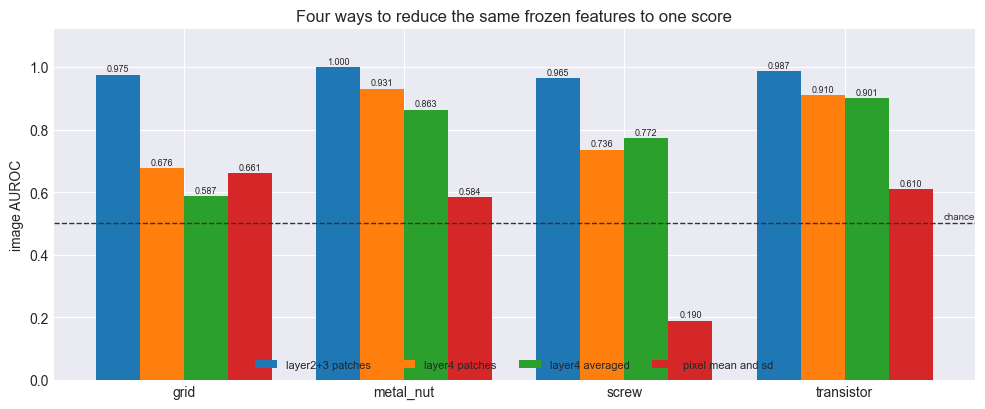

The shipped design beats the skeleton in 4 of 4 categories, by +0.0859 to +0.3876 AUROC,
and the largest gap is grid. Both halves of the notebook 02 arithmetic hold: the coarse
grid loses 0.1686 on its own, and averaging it away moves a further -0.0321.

The two-number floor averages 0.5112 and reaches 0.1898 in screw,
which is below chance rather than near it. A score that ranks defects
consistently lower than sound parts is not noise: brightness and contrast carry
a real signal there, pointing the wrong way.
Nothing in this module depends on it, and it is reported because what a two-number
summary reaches says more about the dataset than the shipped number does on its own.


In [9]:
fig, ax = plt.subplots(figsize=(10, 4.2))
width = 0.2
positions = np.arange(len(CATEGORIES))
for offset, name in enumerate(ladder.index):
    bars = ax.bar(positions + (offset - 1.5) * width, ladder.loc[name, CATEGORIES], width, label=name)
    ax.bar_label(bars, fmt='%.3f', fontsize=6.5, padding=1)
ax.axhline(0.5, color='#333333', linewidth=1, linestyle='--')
ax.text(len(CATEGORIES) - 0.55, 0.515, 'chance', fontsize=7, color='#333333')
ax.set_xticks(positions, CATEGORIES)
ax.set_ylim(0.0, 1.12)
ax.set_ylabel('image AUROC')
ax.set_title('Four ways to reduce the same frozen features to one score')
ax.legend(fontsize=8, ncol=4, loc='lower center')
fig.tight_layout()
save_figure(fig, 'mvtec_model_ladder', subfolder=ASSETS)
plt.show()

gap = ladder.loc['layer2+3 patches', CATEGORIES] - ladder.loc['layer4 averaged', CATEGORIES]
floor = ladder.loc['pixel mean and sd', CATEGORIES]
print(f'The shipped design beats the skeleton in {int((gap > 0).sum())} of {len(CATEGORIES)} '
      f'categories, by {gap.min():+.4f} to {gap.max():+.4f} AUROC,')
print(f'and the largest gap is {gap.idxmax()}. Both halves of the notebook 02 arithmetic hold: '
      f'the coarse')
print(f'grid loses '
      f'{ladder.loc["layer2+3 patches", "mean"] - ladder.loc["layer4 patches", "mean"]:.4f} on its '
      f'own, and averaging it away moves a further '
      f'{ladder.loc["layer4 averaged", "mean"] - ladder.loc["layer4 patches", "mean"]:+.4f}.')
print()
print(f'The two-number floor averages {ladder.loc["pixel mean and sd", "mean"]:.4f} and reaches '
      f'{floor.min():.4f} in {floor.idxmin()},')
if floor.min() < 0.5:
    print('which is below chance rather than near it. A score that ranks defects')
    print('consistently lower than sound parts is not noise: brightness and contrast carry')
    print('a real signal there, pointing the wrong way.')
else:
    print('so brightness and contrast alone do not solve this benchmark.')
print('Nothing in this module depends on it, and it is reported because what a two-number')
print('summary reaches says more about the dataset than the shipped number does on its own.')

## 8. The input size, and the one choice this benchmark cannot make honestly

The module runs at 320 rather than the 224 the other computer-vision modules
use, and the reason comes from notebook 02 section 5 rather than from here: at
320 the most covered `layer2` cell of a defect is essentially all defect in
every category, against 0.84 in the hardest one at 224. That argument is about
the geometry of the mask, not about a score.

**It is still not a defect-free argument, and it should not be dressed up as
one.** Defect masks exist only for the test folder. Any reasoning about how big
a defect is, whatever route it takes, is reasoning from the only labelled
defects this dataset ships.

This is a property of the benchmark rather than of this module. MVTec AD
provides no anomalous validation data at all: a folder of sound parts for
fitting, a folder of mixed parts for reporting, and nothing in between. Every
published number on it, including every number in this notebook, comes from a
pipeline whose design touched the set it is scored on. **The threshold and the
bank size are the two decisions this module was able to keep clean**, and they
are the two that decide what an operator actually sees. The rest is recorded
here as a limitation and repeated in the model card.

The cell below measures the alternative so the size of the effect is on record.

In [10]:
resolution_rows = []
for size in (IMAGE_SIZE, ALTERNATIVE_SIZE):
    for category in (hardest, 'grid'):
        start = time.time()
        scores = image_scores(category, size=size)
        resolution_rows.append({'category': category, 'input': size,
                                'patches_per_image': (size // LAYER_STRIDE) ** 2,
                                'image_auroc': round(float(roc_auc_score(
                                    split[category]['test_label'], scores)), 4),
                                'seconds': round(time.time() - start, 1)})

resolution = pd.DataFrame(resolution_rows).sort_values(['category', 'input'])
print(resolution.to_string(index=False))
print()
pivot = resolution.pivot(index='category', columns='input', values='image_auroc')
change = pivot[IMAGE_SIZE] - pivot[ALTERNATIVE_SIZE]
cost = (resolution.pivot(index='category', columns='input', values='seconds')
        .pipe(lambda frame: frame[IMAGE_SIZE] / frame[ALTERNATIVE_SIZE]))
print(f'The shipped {IMAGE_SIZE} is worth {change.min():+.4f} to {change.max():+.4f} AUROC over '
      f'{ALTERNATIVE_SIZE} and costs {cost.min():.1f} to')
print(f'{cost.max():.1f} times the time. The direction agrees with the mask geometry that chose '
      f'it,')
print('which is the most this measurement can honestly be used for.')

category  input  patches_per_image  image_auroc  seconds
    grid    224                784       0.9465     11.9
    grid    320               1600       0.9749     49.0
   screw    224                784       0.9397     17.1
   screw    320               1600       0.9650     47.9

The shipped 320 is worth +0.0253 to +0.0284 AUROC over 224 and costs 2.8 to
4.1 times the time. The direction agrees with the mask geometry that chose it,
which is the most this measurement can honestly be used for.


## 9. The operating point, read off sound parts and applied to test once

This is where the casting lesson is applied rather than discussed.

Casting chose its threshold by searching a cost curve computed on scored data.
The curve was nearly flat, the scores moved between runs of identical code, and
the chosen point moved with them by a factor of five. Two sessions of work
established that no rule reading those scores can be stable while the curve
underneath moves.

**So this module does not search.** It states a budget and reads the threshold
off the calibration distribution:

    the threshold is the lowest score that flags no more than 5 per cent
    of the sound parts the model does not hold

There is no optimum, so there is nothing for run-to-run noise to relocate.
Section 12 measures whether it moves.

**Two things this rule is not.** It is not calibrated against defects, because
that would be choosing the threshold on the data the result is reported on. And
5 per cent is not a plant false-alarm rate: notebook 01 measured these test
folders at 40 to 81 per cent defective, which is nothing like a production line,
and notebook 02 measured calibration sets of 64 to 96 parts, too few to state a
1 per cent budget as anything but the single highest observation.

A second edge comes from the same distribution at no extra cost: the highest
score any sound calibration part reached. A part above that has no precedent
among sound parts at all, and section 14 uses the two edges as the priority
bands.

In [11]:
operating, calibration_scores = [], {}
for category in CATEGORIES:
    scores = score_maps(features(split[category]['calibration']), banks[category]).max(axis=(1, 2))
    calibration_scores[category] = scores
    threshold = float(np.quantile(scores, 1 - FALSE_ALARM_BUDGET, method='higher'))
    operating.append({'category': category, 'calibration_parts': len(scores),
                      'median_normal': round(float(np.median(scores)), 4),
                      'threshold': round(threshold, 4),
                      'ceiling': round(float(scores.max()), 4),
                      'flagged_on_calibration': int((scores > threshold).sum()),
                      'realised_false_alarm': round(float((scores > threshold).mean()), 4)})

operating = pd.DataFrame(operating).set_index('category')
THRESHOLD = operating['threshold'].to_dict()
CEILING = operating['ceiling'].to_dict()
print(operating.to_string())
print()
print(f'The budget is {FALSE_ALARM_BUDGET:.0%} and the realised rate on the calibration parts is '
      f'{operating["realised_false_alarm"].min():.1%} to')
print(f'{operating["realised_false_alarm"].max():.1%}, below the budget in every category because '
      f'the threshold is taken at an')
print('observed score rather than interpolated between two. Neither edge has seen a')
print('defect: both are properties of sound parts alone.')

            calibration_parts  median_normal  threshold  ceiling  flagged_on_calibration  realised_false_alarm
category                                                                                                      
grid                       79         1.5998     1.7574   1.7824                       3                0.0380
metal_nut                  66         1.8766     2.0246   2.0390                       3                0.0455
screw                      96         1.5205     1.7111   1.8896                       4                0.0417
transistor                 64         1.8069     2.0822   2.2878                       3                0.0469

The budget is 5% and the realised rate on the calibration parts is 3.8% to
4.7%, below the budget in every category because the threshold is taken at an
observed score rather than interpolated between two. Neither edge has seen a
defect: both are properties of sound parts alone.


## 10. The test folders, scored once

The four thresholds above are now applied unchanged to the folders the dataset
ships as `test/`. Nothing below is tuned, and nothing above is revisited.

In [12]:
test_maps, test_scores, results = {}, {}, []
for category in CATEGORIES:
    maps = score_maps(features(split[category]['test']), banks[category])
    scores = maps.max(axis=(1, 2))
    labels = split[category]['test_label']
    flagged = scores > THRESHOLD[category]
    test_maps[category], test_scores[category] = maps, scores
    results.append({
        'category': category,
        'image_auroc': round(float(roc_auc_score(labels, scores)), 4),
        'defects_found': int((flagged & (labels == 1)).sum()),
        'defects_total': int((labels == 1).sum()),
        'recall': round(float(flagged[labels == 1].mean()), 4),
        'false_alarms': int((flagged & (labels == 0)).sum()),
        'sound_total': int((labels == 0).sum()),
        'false_alarm_rate': round(float(flagged[labels == 0].mean()), 4)})

results = pd.DataFrame(results).set_index('category')
print(results.to_string())
print()
print(f'Mean image AUROC over the four categories: {results["image_auroc"].mean():.4f} '
      f'(range {results["image_auroc"].min():.4f} to {results["image_auroc"].max():.4f}).')
control = float((results['image_auroc'] - ladder.loc['layer2+3 patches', CATEGORIES]).abs().max())
print(f'Section 7 rebuilt the same design from scratch and scored it independently; the two')
print(f'agree to {control:.4f} AUROC, which is the control on the stored banks.')
print()
print(f'The false-alarm rate on the test folders is {results["false_alarm_rate"].min():.1%} to '
      f'{results["false_alarm_rate"].max():.1%}, against a budget of')
print(f'{FALSE_ALARM_BUDGET:.0%} set on the calibration parts. Where it is higher, the threshold '
      f'is transferring worse')
print('than the budget promises, and that gap is the honest measure of how far a quantile')
print(f'of {operating["calibration_parts"].min()} to {operating["calibration_parts"].max()} '
      f'sound parts carries to a folder it never saw.')

            image_auroc  defects_found  defects_total  recall  false_alarms  sound_total  false_alarm_rate
category                                                                                                  
grid             0.9749             54             57  0.9474             3           21            0.1429
metal_nut        1.0000             93             93  1.0000             5           22            0.2273
screw            0.9650            103            119  0.8655             4           41            0.0976
transistor       0.9871             39             40  0.9750             8           60            0.1333

Mean image AUROC over the four categories: 0.9817 (range 0.9650 to 1.0000).
Section 7 rebuilt the same design from scratch and scored it independently; the two
agree to 0.0000 AUROC, which is the control on the stored banks.

The false-alarm rate on the test folders is 9.8% to 22.7%, against a budget of
5% set on the calibration parts. Where it is higher,

  ✓ Saved → assets\cv\mvtec_model_roc.png


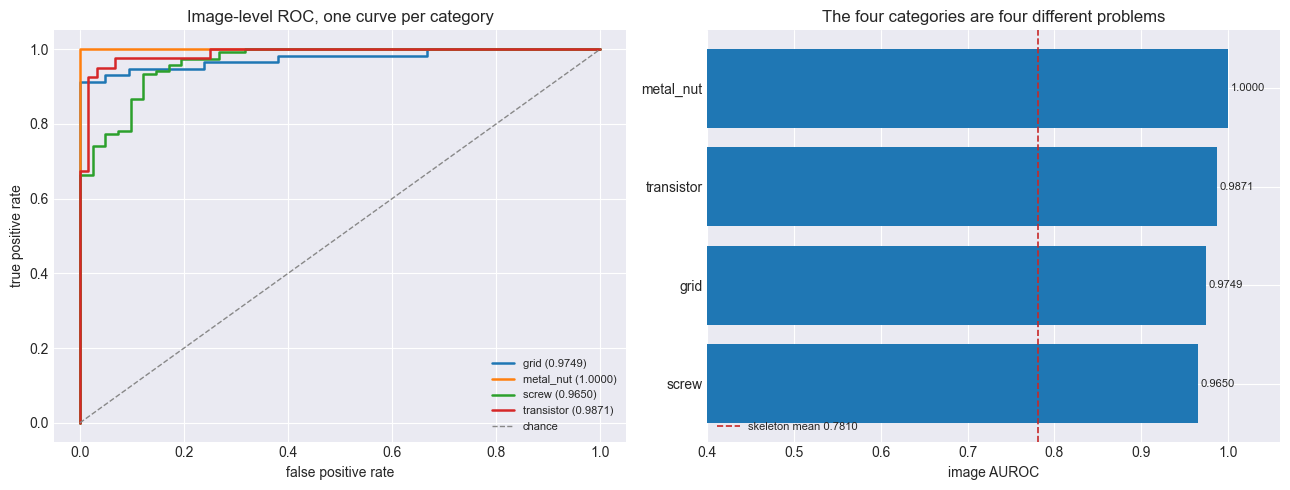

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for category in CATEGORIES:
    fpr, tpr, _ = roc_curve(split[category]['test_label'], test_scores[category])
    axes[0].plot(fpr, tpr, linewidth=1.8,
                 label=f'{category} ({results.loc[category, "image_auroc"]:.4f})')
axes[0].plot([0, 1], [0, 1], '--', color='#888888', linewidth=1, label='chance')
axes[0].set_xlabel('false positive rate')
axes[0].set_ylabel('true positive rate')
axes[0].set_title('Image-level ROC, one curve per category')
axes[0].legend(fontsize=8, loc='lower right')

order = results['image_auroc'].sort_values()
axes[1].barh(order.index, order.to_numpy(), color='#1f77b4')
axes[1].bar_label(axes[1].containers[0], fmt='%.4f', fontsize=8, padding=2)
axes[1].axvline(ladder.loc['layer4 averaged', 'mean'], color='#c62828', linestyle='--',
                linewidth=1.2, label=f'skeleton mean {ladder.loc["layer4 averaged", "mean"]:.4f}')
axes[1].set_xlim(0.4, 1.06)
axes[1].set_xlabel('image AUROC')
axes[1].set_title('The four categories are four different problems')
axes[1].legend(fontsize=8, loc='lower left')
fig.tight_layout()
save_figure(fig, 'mvtec_model_roc', subfolder=ASSETS)
plt.show()

  ✓ Saved → assets\cv\mvtec_operating_point.png


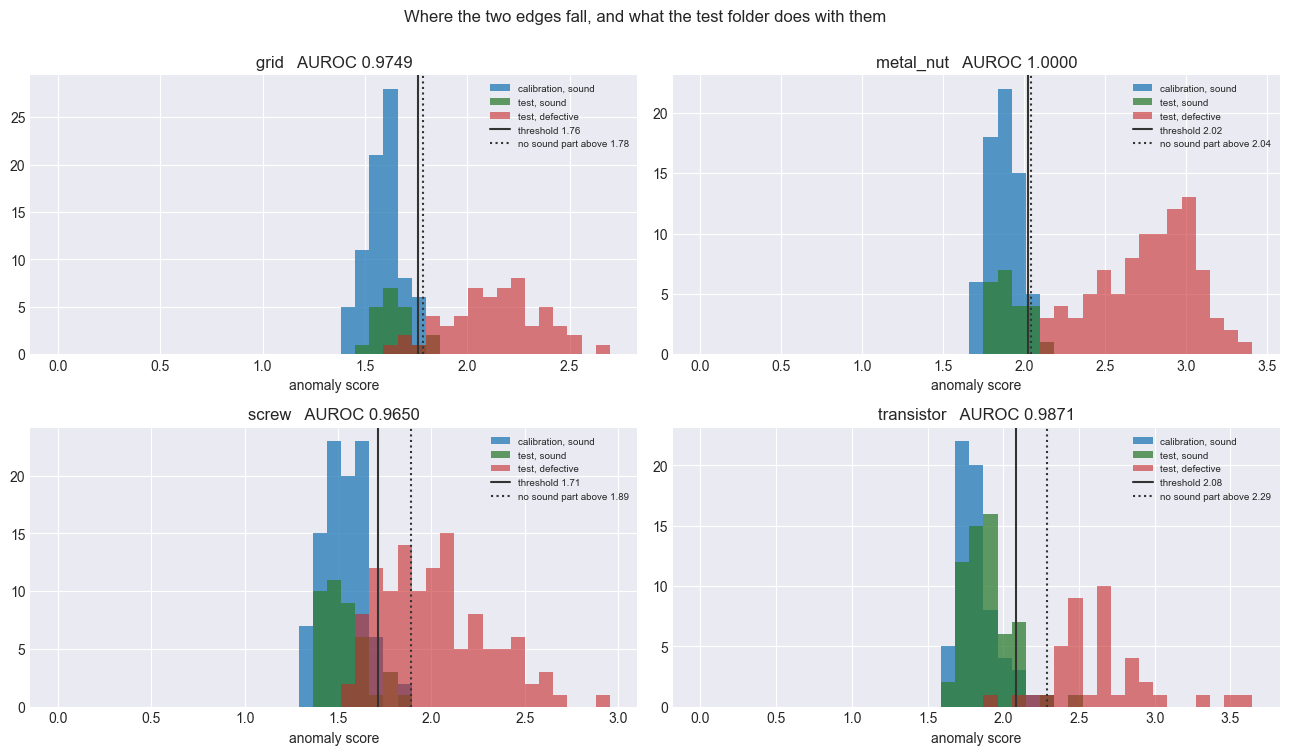

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7.5))
for axis, category in zip(axes.ravel(), CATEGORIES):
    labels = split[category]['test_label']
    top = max(test_scores[category].max(), calibration_scores[category].max()) * 1.02
    bins = np.linspace(0, top, 40)
    axis.hist(calibration_scores[category], bins=bins, alpha=0.75, color='#1f77b4',
              label='calibration, sound')
    axis.hist(test_scores[category][labels == 0], bins=bins, alpha=0.75, color='#2e7d32',
              label='test, sound')
    axis.hist(test_scores[category][labels == 1], bins=bins, alpha=0.6, color='#c62828',
              label='test, defective')
    axis.axvline(THRESHOLD[category], color='#333333', linewidth=1.5,
                 label=f'threshold {THRESHOLD[category]:.2f}')
    axis.axvline(CEILING[category], color='#333333', linestyle=':', linewidth=1.5,
                 label=f'no sound part above {CEILING[category]:.2f}')
    axis.set_title(f'{category}   AUROC {results.loc[category, "image_auroc"]:.4f}')
    axis.set_xlabel('anomaly score')
    axis.legend(fontsize=7)
fig.suptitle('Where the two edges fall, and what the test folder does with them', y=1.001)
fig.tight_layout()
save_figure(fig, 'mvtec_operating_point', subfolder=ASSETS)
plt.show()

## 11. Where, not only whether

The event contract carries one scalar, so `risk_score` is the image score and
nothing about the contract changes. But this dataset ships a pixel mask for
every defective test image, and the method produces a score for every grid cell
on the way to the image score, so the localisation is already computed. Throwing
it away would repeat what the NEU card records about itself: that module
discarded 4,189 bounding boxes and has nothing to tell an operator asking where.

The per-cell scores are resampled to the input resolution and smoothed, then
scored against the shipped masks as a pixel-level AUROC over every pixel of
every test image, sound ones included. Two things about that number. It is
computed at the model's input resolution rather than at native resolution, so it
is not comparable with published MVTec figures. And pixel AUROC is generous by
construction: defect pixels are a small minority, so a map that is roughly right
everywhere scores well. The share is printed beside it for that reason.

In [15]:
def mask_stack(category):
    """Ground truth at the model's resolution: zeros for a sound part."""
    stack = np.zeros((len(split[category]['test']), IMAGE_SIZE, IMAGE_SIZE), dtype=bool)
    for index, (path, defect) in enumerate(zip(split[category]['test'],
                                               split[category]['test_defect'])):
        if defect == 'good':
            continue
        mask_path = RAW_DIR / category / 'ground_truth' / defect / f'{path.stem}_mask.png'
        with Image.open(mask_path) as mask:
            stack[index] = np.asarray(mask.convert('L').resize((IMAGE_SIZE, IMAGE_SIZE),
                                                               Image.NEAREST)) > 0
    return stack


def pixel_map(maps):
    """Per-cell scores resampled to the input resolution and smoothed."""
    tensor = F.interpolate(torch.as_tensor(maps).unsqueeze(1), size=(IMAGE_SIZE, IMAGE_SIZE),
                           mode='bilinear', align_corners=False)
    kernel = 4 * SMOOTHING_SIGMA + 1
    return gaussian_blur(tensor, kernel_size=[kernel, kernel],
                         sigma=[float(SMOOTHING_SIGMA)] * 2).squeeze(1).numpy()


pixel_rows, pixel_maps = [], {}
for category in CATEGORIES:
    truth = mask_stack(category)
    pixel_maps[category] = pixel_map(test_maps[category])
    pixel_rows.append({
        'category': category,
        'pixel_auroc': round(float(roc_auc_score(truth.ravel(), pixel_maps[category].ravel())), 4),
        'defect_pixels': int(truth.sum()),
        'total_pixels': int(truth.size),
        'defect_share': round(float(truth.mean()), 5)})
    del truth

pixels = pd.DataFrame(pixel_rows).set_index('category')
print(pixels.to_string())
print()
print(f'Mean pixel AUROC {pixels["pixel_auroc"].mean():.4f}, on maps where defect pixels are')
print(f'{pixels["defect_share"].min():.3%} to {pixels["defect_share"].max():.3%} of the total.')

            pixel_auroc  defect_pixels  total_pixels  defect_share
category                                                          
grid             0.9841          55087       7987200       0.00690
metal_nut        0.9842        1379988      11776000       0.11719
screw            0.9948          40908      16384000       0.00250
transistor       0.9322         490701      10240000       0.04792

Mean pixel AUROC 0.9738, on maps where defect pixels are
0.250% to 11.719% of the total.


  ✓ Saved → assets\cv\mvtec_model_localisation.png


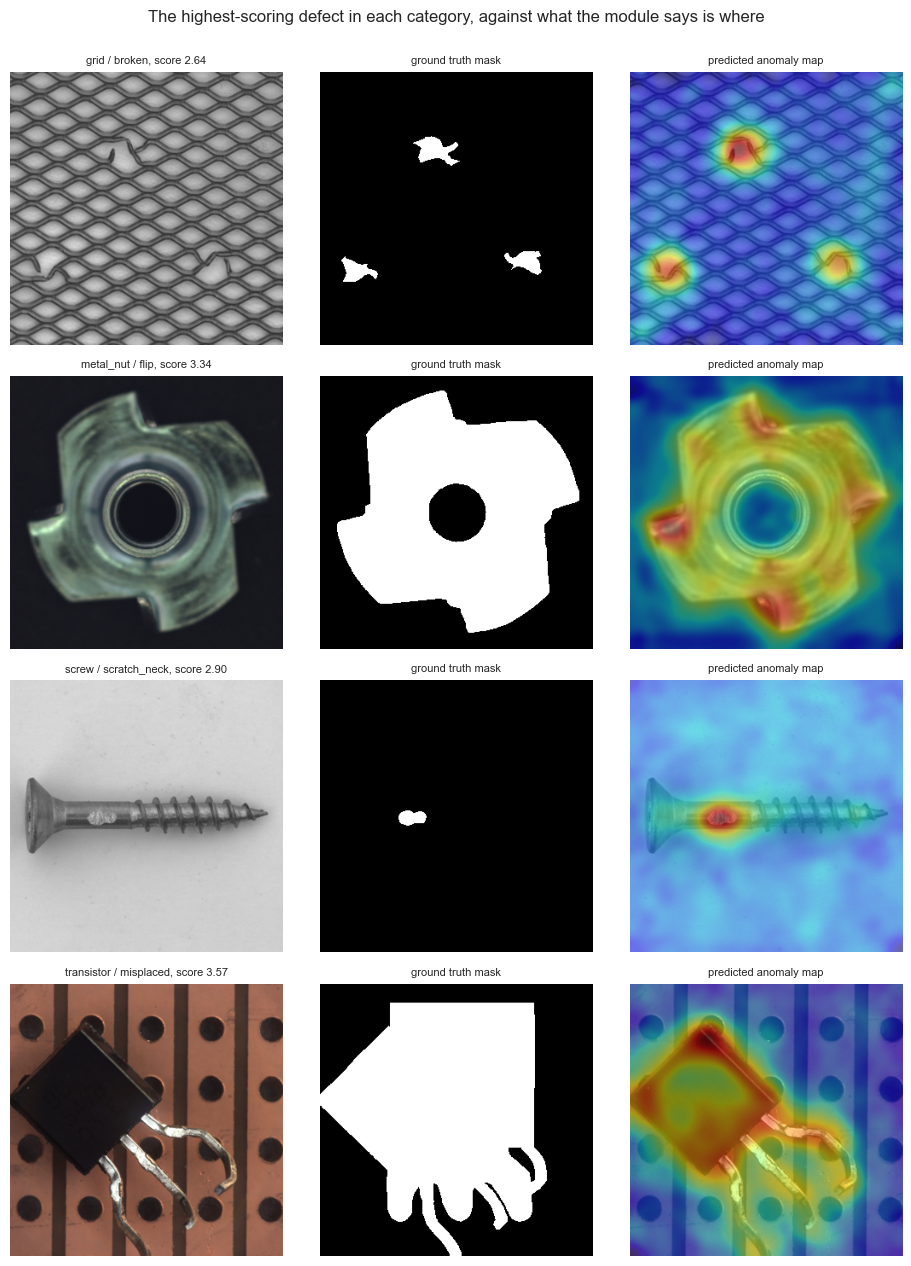

In [16]:
fig, axes = plt.subplots(len(CATEGORIES), 3, figsize=(9.5, 3.15 * len(CATEGORIES)))
for row, category in enumerate(CATEGORIES):
    labels = split[category]['test_label']
    pick = int(np.flatnonzero(labels == 1)[np.argmax(test_scores[category][labels == 1])])
    path = split[category]['test'][pick]
    defect = split[category]['test_defect'][pick]
    image = Image.open(path).convert('RGB').resize((IMAGE_SIZE, IMAGE_SIZE))
    with Image.open(RAW_DIR / category / 'ground_truth' / defect / f'{path.stem}_mask.png') as mask:
        truth = np.asarray(mask.convert('L').resize((IMAGE_SIZE, IMAGE_SIZE), Image.NEAREST)) > 0
    axes[row][0].imshow(image)
    axes[row][0].set_title(f'{category} / {defect}, score {test_scores[category][pick]:.2f}',
                           fontsize=8)
    axes[row][1].imshow(truth, cmap='gray')
    axes[row][1].set_title('ground truth mask', fontsize=8)
    axes[row][2].imshow(image)
    axes[row][2].imshow(pixel_maps[category][pick], cmap='jet', alpha=0.5)
    axes[row][2].set_title('predicted anomaly map', fontsize=8)
    for axis in axes[row]:
        axis.set_xticks([])
        axis.set_yticks([])
fig.suptitle('The highest-scoring defect in each category, against what the module says is where',
             y=1.001)
fig.tight_layout()
save_figure(fig, 'mvtec_model_localisation', subfolder=ASSETS)
plt.show()

## 12. Does this reproduce

Casting's fine-tuned arm never returned the same numbers twice while its frozen
arm was bit-identical every time, which located the non-determinism in the
convolution backward pass. This module has no backward pass at all, so the
prediction is that it reproduces exactly. That is a prediction, and it is worth
nothing until it is run.

The whole pipeline runs again from the same seed in the same session: features,
coreset, threshold, scores.

In [17]:
repeat = []
for category in CATEGORIES:
    again_full = features(split[category]['bank'])
    again_order = coreset_order(again_full, int(round(again_full.shape[0] * max(BANK_BUDGETS))))
    again_bank = again_full[again_order[:banks[category].shape[0]]].contiguous()
    again_calibration = score_maps(features(split[category]['calibration']),
                                   again_bank).max(axis=(1, 2))
    again_threshold = float(np.quantile(again_calibration, 1 - FALSE_ALARM_BUDGET, method='higher'))
    again_scores = score_maps(features(split[category]['test']), again_bank).max(axis=(1, 2))
    repeat.append({
        'category': category,
        'bank_identical': bool(torch.equal(again_bank, banks[category])),
        'max_score_difference': float(np.abs(again_scores - test_scores[category]).max()),
        'threshold_moved': round(again_threshold - THRESHOLD[category], 6),
        'auroc_run_2': round(float(roc_auc_score(split[category]['test_label'], again_scores)), 4),
        'decisions_changed': int(((test_scores[category] > THRESHOLD[category])
                                  != (again_scores > again_threshold)).sum())})
    del again_full, again_bank
    release()

repeat = pd.DataFrame(repeat).set_index('category')
# Two verdicts, not one. The banks and the test scores are compared directly; the
# thresholds are quantiles of the calibration scores, which this comparison never
# looks at, so a threshold can move while every number above it is identical. A
# single flag covering both would let the smaller claim carry the larger one.
identical = bool((repeat['max_score_difference'] == 0).all() and repeat['bank_identical'].all())
thresholds_fixed = bool((repeat['threshold_moved'] == 0).all())
print(repeat.to_string())
print()
print(f'banks identical in every category : {bool(repeat["bank_identical"].all())}')
print(f'largest difference on a test score: {repeat["max_score_difference"].max():.3e}')
print(f'largest threshold movement        : {repeat["threshold_moved"].abs().max():.3e}')
print(f'decisions changed                 : {int(repeat["decisions_changed"].sum())} of '
      f'{int(results["defects_total"].sum() + results["sound_total"].sum())}')
print()
if identical:
    print('The banks and the test scores reproduce exactly, and the reason is structural')
    print('rather than lucky: there is no training, so there is no convolution backward')
    print('pass, and the forward pass on a fixed input is deterministic on this device.')
    if thresholds_fixed:
        print('Casting spans 0.0436 to 0.2203 across four runs of one seed; these four')
        print('thresholds do not move at all.')
    else:
        print(f'The thresholds are the exception, by up to '
              f'{repeat["threshold_moved"].abs().max():.1e}: each is a quantile of the')
        print('calibration scores, which the second pass recomputes and which the row above')
        print('does not cover. Casting spans 0.0436 to 0.2203 across four runs of one seed,')
        print('so the comparison holds by four orders of magnitude, and no decision moves.')
else:
    print('The module does not reproduce exactly, which the prediction did not expect. The')
    print('table above locates the difference, and section 15 records it in the metrics file')
    print('rather than reporting a single run as if it were the result.')

            bank_identical  max_score_difference  threshold_moved  auroc_run_2  decisions_changed
category                                                                                         
grid                  True                   0.0        -0.000010       0.9749                  0
metal_nut             True                   0.0        -0.000032       1.0000                  0
screw                 True                   0.0        -0.000034       0.9650                  0
transistor            True                   0.0         0.000008       0.9871                  0

banks identical in every category : True
largest difference on a test score: 0.000e+00
largest threshold movement        : 3.400e-05
decisions changed                 : 0 of 453

The banks and the test scores reproduce exactly, and the reason is structural
rather than lucky: there is no training, so there is no convolution backward
pass, and the forward pass on a fixed input is deterministic on this device.


## 13. What the calibration holdout costs

Thirty per cent of the sound training parts are kept out of the bank so the
threshold has somewhere to come from. That is a real cost: a smaller bank covers
less of the normal variation. The cell measures it by building a bank from every
sound training part and scoring the same test folder.

The larger bank cannot be shipped: with no held-out sound parts there is no
honest threshold. What this gives is the price of having one.

In [18]:
holdout_rows = []
for category in CATEGORIES:
    scores = image_scores(category, bank_paths=split[category]['all_good'])
    holdout_rows.append({'category': category,
                         'bank_70_percent': results.loc[category, 'image_auroc'],
                         'bank_100_percent': round(float(roc_auc_score(
                             split[category]['test_label'], scores)), 4)})

holdout = pd.DataFrame(holdout_rows).set_index('category')
holdout['cost'] = (holdout['bank_70_percent'] - holdout['bank_100_percent']).round(4)
print(holdout.to_string())
print()
print(f'The holdout costs {holdout["cost"].min():+.4f} to {holdout["cost"].max():+.4f} AUROC, '
      f'mean {holdout["cost"].mean():+.4f}. That is what')
print('a threshold with a stated basis is worth paying, and it is a number rather than')
print('an argument.')

            bank_70_percent  bank_100_percent    cost
category                                             
grid                 0.9749            0.9791 -0.0042
metal_nut            1.0000            0.9976  0.0024
screw                0.9650            0.9785 -0.0135
transistor           0.9871            0.9937 -0.0066

The holdout costs -0.0135 to +0.0024 AUROC, mean -0.0055. That is what
a threshold with a stated basis is worth paying, and it is a number rather than
an argument.


## 14. The priority bands the event adapter publishes

Two decisions fix the mapping, and both are constrained by what an anomaly
detector can honestly say.

**The module suppresses what it does not flag.** Casting and Scania publish only
what they flag, because a pass is the normal case and publishing every pass
would bury the incident store. This dataset has a sound class and the whole
point of the module is the sound-or-not decision, so it behaves the same way.
NEU publishes everything only because NEU has no sound class at all.

**Priority comes from the score, and it says nothing about severity.** Ranking a
scratch against a bent lead against a flipped nut by how dangerous each is would
need engineering judgement about parts this project does not have, and an
invented ranking would be worse than none. What the module can honestly say is
whether it has ever seen a sound part score this high:

    score above the ceiling    no sound calibration part reached this, P2
    score above the threshold  inside the range sound parts reach, P3

Both edges come from the calibration set of section 9 and neither has seen a
defect. There is no P1 band, and that is deliberate: P1 in the charter means
safety-relevant, and a detector fitted only to sound parts has no basis for
calling one defect more dangerous than another.

The scalar the contract carries is bounded and the threshold sits at exactly
0.5:

    risk_score = score / (score + threshold)

which is monotone in the score, never saturates, and needs no constant beyond
the threshold the module already publishes.

In [19]:
def priority_for(score, threshold, ceiling):
    return 'P2' if score > ceiling else ('P3' if score > threshold else None)


bands = []
risk = {c: test_scores[c] / (test_scores[c] + THRESHOLD[c]) for c in CATEGORIES}
for category in CATEGORIES:
    labels = split[category]['test_label']
    priority = [priority_for(s, THRESHOLD[category], CEILING[category])
                for s in test_scores[category]]
    published = np.array([p is not None for p in priority])
    bands.append({'category': category,
                  'events': int(published.sum()),
                  'P2': sum(p == 'P2' for p in priority),
                  'P3': sum(p == 'P3' for p in priority),
                  'suppressed': int((~published).sum()),
                  'defects_suppressed': int((~published & (labels == 1)).sum()),
                  'sound_published': int((published & (labels == 0)).sum())})

bands = pd.DataFrame(bands).set_index('category')
published_risk = np.concatenate([risk[c][test_scores[c] > THRESHOLD[c]] for c in CATEGORIES])
print(bands.to_string())
print()
print(f'{bands["events"].sum()} events from '
      f'{int(bands["events"].sum() + bands["suppressed"].sum())} test images: '
      f'{bands["P2"].sum()} P2 and {bands["P3"].sum()} P3.')
print(f'{bands["defects_suppressed"].sum()} defective parts are suppressed, which is the recall '
      f'gap of section 10 seen from the')
print(f'other side, and {bands["sound_published"].sum()} sound parts reach an operator as a false '
      f'alarm.')
print(f'risk_score across the published events runs {published_risk.min():.3f} to '
      f'{published_risk.max():.3f}, with the threshold')
print('at 0.500 by construction.')

            events  P2  P3  suppressed  defects_suppressed  sound_published
category                                                                   
grid            57  55   2          21                   3                3
metal_nut       98  97   1          17                   0                5
screw          107  73  34          53                  16                4
transistor      47  37  10          53                   1                8

309 events from 453 test images: 262 P2 and 47 P3.
20 defective parts are suppressed, which is the recall gap of section 10 seen from the
other side, and 20 sound parts reach an operator as a false alarm.
risk_score across the published events runs 0.500 to 0.632, with the threshold
at 0.500 by construction.


## 15. Write the artifacts

Three kinds of file: the four memory banks, which are the model; the metrics
file every downstream document cites; and the prediction table the event adapter
reads. Nothing is overwritten, because nothing existed before this run.

In [20]:
def jsonable(value):
    """pandas hands back numpy scalars; json does not know them."""
    if isinstance(value, np.bool_):
        return bool(value)
    if isinstance(value, np.integer):
        return int(value)
    if isinstance(value, np.floating):
        return float(value)
    if isinstance(value, np.ndarray):
        return value.tolist()
    raise TypeError(f'not serialisable: {type(value)}')


PROC_DIR.mkdir(parents=True, exist_ok=True)
written = []
for category in CATEGORIES:
    path = MODEL_DIR / f'{MODEL_VERSION}_{category}_bank.npy'
    np.save(path, banks[category].numpy())
    written.append(path)

meta = {
    'dataset': 'MVTec AD, four categories: grid, metal_nut, screw, transistor',
    'task': 'unsupervised anomaly detection, fitted on sound parts only',
    'architecture': ('resnet18 ImageNet backbone, frozen; layer2 and layer3 with 3x3 local '
                     'aggregation concatenated on the layer2 grid; greedy coreset memory bank; '
                     'image score is the largest per-patch nearest-neighbour distance'),
    'trained': False,
    'training_note': ('nothing is fitted to MVTec. The module stores feature vectors taken from '
                      'sound parts and computes a distance, so there is no loss, no epoch and '
                      'no learning rate.'),
    'image_size': IMAGE_SIZE,
    'layers': list(LAYERS),
    'patches_per_image': GRID * GRID,
    'seed': SEED,
    'categories': CATEGORIES,
    'split_note': ('the dataset ships train/ with sound parts only and test/ with both. The '
                   f'train folder is cut {1 - CALIBRATION_FRACTION:.0%}/{CALIBRATION_FRACTION:.0%} '
                   f'at seed {SEED} into a memory bank and a calibration set of sound parts the '
                   'bank does not hold; the shipped test/ folder is scored once.'),
    'composition': composition.to_dict(orient='index'),
    'memory_bank': {
        'rule': (f'the smallest budget at which the median score of the held-out sound parts is '
                 f'within {BANK_TOLERANCE:.0%} of what the complete bank gives them'),
        'basis': 'chosen on sound parts alone, with no defect label involved',
        'budgets_measured': list(BANK_BUDGETS),
        'sweep': budgets.to_dict(orient='records'),
        'per_category': bank_table.to_dict(orient='index'),
        'cost_after_the_fact': {'measured_on': hardest,
                                'variants': subsample.to_dict(orient='records')},
    },
    'benchmark_difficulty': {
        'note': ('the same frozen features reduced four ways on the same test folders, so the '
                 'shipped design can be read against the alternatives rather than against chance'),
        'image_auroc': ladder.to_dict(orient='index'),
    },
    'input_resolution': {
        'note': (f'the module ships at {IMAGE_SIZE}, chosen from the mask geometry in notebook 02 '
                 f'section 5; {ALTERNATIVE_SIZE} measured here for the record'),
        'measurements': resolution.to_dict(orient='records'),
    },
    'operating_point': {
        'rule': (f'the lowest score that flags no more than {FALSE_ALARM_BUDGET:.0%} of the '
                 'calibration parts, which are sound parts the memory bank does not hold'),
        'basis': ('declared budget on sound parts, read off the calibration quantile. No search '
                  'over a cost curve, and no defect involved in either edge.'),
        'false_alarm_budget': FALSE_ALARM_BUDGET,
        'risk_score_formula': 'score / (score + threshold), so the threshold is 0.5',
        'per_category': operating.to_dict(orient='index'),
    },
    'test_performance': {
        'measured_on': 'the folder the dataset ships as test/, scored once',
        'per_category': results.to_dict(orient='index'),
        'mean_image_auroc': round(float(results['image_auroc'].mean()), 4),
        'pixel_localisation': pixels.to_dict(orient='index'),
        'mean_pixel_auroc': round(float(pixels['pixel_auroc'].mean()), 4),
        'pixel_note': (f'computed at {IMAGE_SIZE} by {IMAGE_SIZE} over every pixel of every test '
                       'image, sound ones included, so it is not comparable with published MVTec '
                       'figures at native resolution'),
    },
    'priority_bands': bands.to_dict(orient='index'),
    'calibration_holdout_cost': holdout.to_dict(orient='index'),
    'reproduction': {
        'note': 'the whole pipeline run twice from the same seed in the same session',
        'exact': identical,
        'per_category': repeat.to_dict(orient='index'),
    },
    'benchmark_limitation': ('MVTec AD ships no anomalous validation data, so every design choice '
                             'that reasons about defects reasons from the folder the module is '
                             'scored on. The threshold and the memory-bank budget are the two '
                             'choices this module makes on sound parts alone.'),
}
meta_path = MODEL_DIR / 'mvtec_cv_meta.json'
meta_path.write_text(json.dumps(meta, indent=2, default=jsonable), encoding='utf-8')
written.append(meta_path)

predictions_path = PROC_DIR / 'test_mvtec_predictions.npz'
np.savez(
    predictions_path,
    paths=np.array([p.resolve().relative_to(REPO_ROOT).as_posix()
                    for c in CATEGORIES for p in split[c]['test']]),
    category=np.array([c for c in CATEGORIES for _ in split[c]['test']]),
    defect=np.array([d for c in CATEGORIES for d in split[c]['test_defect']]),
    score=np.concatenate([test_scores[c] for c in CATEGORIES]).astype(np.float32),
    risk=np.concatenate([risk[c] for c in CATEGORIES]).astype(np.float32),
    threshold=np.array([THRESHOLD[c] for c in CATEGORIES for _ in split[c]['test']],
                       dtype=np.float32),
    ceiling=np.array([CEILING[c] for c in CATEGORIES for _ in split[c]['test']], dtype=np.float32),
    true_label=np.concatenate([split[c]['test_label'] for c in CATEGORIES]).astype(np.int64),
    flagged_area=np.concatenate([(test_maps[c] > THRESHOLD[c]).mean(axis=(1, 2))
                                 for c in CATEGORIES]).astype(np.float32))
written.append(predictions_path)

for path in written:
    print(f'{path.stat().st_size / 1e6:>8.3f} MB  {path.as_posix()}')
stored = np.load(predictions_path, allow_pickle=False)
print()
print(f'prediction table: {len(stored["paths"])} rows, first image {stored["paths"][0]}')
print(f'it resolves from the repository root: {(REPO_ROOT / str(stored["paths"][0])).is_file()}')

  22.733 MB  ../../../models/checkpoints/mvtec/mvtec_patchcore_v1_grid_bank.npy
  18.924 MB  ../../../models/checkpoints/mvtec/mvtec_patchcore_v1_metal_nut_bank.npy
  27.525 MB  ../../../models/checkpoints/mvtec/mvtec_patchcore_v1_screw_bank.npy
  18.309 MB  ../../../models/checkpoints/mvtec/mvtec_patchcore_v1_transistor_bank.npy
   0.014 MB  ../../../models/checkpoints/mvtec/mvtec_cv_meta.json
   0.167 MB  ../../../data/05_mvtec/processed/test_mvtec_predictions.npz

prediction table: 453 rows, first image data/05_mvtec/raw/grid/test/bent/000.png
it resolves from the repository root: True


## 16. Log the runs

Into the same SQLite tracking store as the other four modules, under the
experiment name the README advertised before this module existed. One run per
category, because the four are four models with four thresholds and averaging
them into a single run would hide exactly what section 10 is about.

In [21]:
import mlflow

mlflow.set_tracking_uri(get_mlflow_uri())
mlflow.set_experiment(EXPERIMENT_NAME)
logged = []
for category in CATEGORIES:
    with mlflow.start_run(run_name=f'{MODEL_VERSION}_{category}'):
        mlflow.set_tags({'dataset': 'mvtec_ad', 'task': 'anomaly_detection',
                         'method': 'patchcore_coreset_knn', 'framework': 'pytorch',
                         'architecture': 'resnet18_layer2_layer3', 'category': category,
                         'department': 'Component Inspection',
                         'business_domain': 'visual_inspection', 'trained': 'false'})
        mlflow.log_params({'image_size': IMAGE_SIZE, 'layers': '+'.join(LAYERS),
                           'bank_budget': float(bank_table.loc[category, 'budget']),
                           'seed': SEED, 'false_alarm_budget': FALSE_ALARM_BUDGET,
                           'calibration_fraction': CALIBRATION_FRACTION,
                           'bank_images': int(bank_table.loc[category, 'images']),
                           'bank_vectors': int(bank_table.loc[category, 'kept'])})
        mlflow.log_metrics({
            'image_auroc': float(results.loc[category, 'image_auroc']),
            'pixel_auroc': float(pixels.loc[category, 'pixel_auroc']),
            'threshold': float(THRESHOLD[category]),
            'ceiling': float(CEILING[category]),
            'recall': float(results.loc[category, 'recall']),
            'false_alarm_rate': float(results.loc[category, 'false_alarm_rate']),
            'events_published': int(bands.loc[category, 'events'])})
        logged.append(mlflow.active_run().info.run_id)

with mlflow.start_run(run_name=f'{MODEL_VERSION}_summary'):
    mlflow.log_metrics({'mean_image_auroc': float(results['image_auroc'].mean()),
                        'mean_pixel_auroc': float(pixels['pixel_auroc'].mean()),
                        'skeleton_mean_image_auroc': float(ladder.loc['layer4 averaged', 'mean'])})
    mlflow.log_artifact(str(meta_path))
    logged.append(mlflow.active_run().info.run_id)
print(f'logged {len(logged)} runs to experiment {EXPERIMENT_NAME}')
print(f'run ids: {logged}')

logged 5 runs to experiment arkon-cv-mvtec
run ids: ['e03f98ca88c34f5dbf6111f2ec33280e', '32e0dee0a3ce48a1ada87dda82035479', 'e6e0caafb5aa4416a58a721a32b7aa17', '26c638dac60947b59de37d535c7187db', 'd94b51a20de04fccacf05eba05329609']


## 17. Results

In [22]:
print(f'1. Four anomaly detectors, one per category, holding {bank_table["kept"].sum():,} feature '
      f'vectors in')
print(f'   {bank_table["megabytes"].sum():.1f} MB and no trained weights. Mean image AUROC '
      f'{results["image_auroc"].mean():.4f} on the shipped test')
print(f'   folders, from {results["image_auroc"].min():.4f} in {results["image_auroc"].idxmin()} '
      f'to {results["image_auroc"].max():.4f} in {results["image_auroc"].idxmax()}, and mean '
      f'pixel AUROC {pixels["pixel_auroc"].mean():.4f}.')
print(f'2. The four numbers are four results, not one. They differ by '
      f'{results["image_auroc"].max() - results["image_auroc"].min():.4f} AUROC, the categories')
print('   are four imaging setups with their own failure modes, and notebook 01 measured')
print('   a standard error of 0.016 to 0.025 on each. A single average would hide both.')
print(f'3. The skeleton design in this folder, layer4 averaged over the frame, reaches '
      f'{ladder.loc["layer4 averaged", "mean"]:.4f}')
print(f'   against {ladder.loc["layer2+3 patches", "mean"]:.4f} for the shipped one, and notebook '
      f'02 predicted that from the masks')
print(f'   alone. The largest gap is {gap.idxmax()}, {gap.max():+.4f}.')
print('4. The memory bank was sized without a single defect: the budget is the smallest')
print(f'   at which held-out sound parts score within {BANK_TOLERANCE:.0%} of what the complete '
      f'bank gives them.')
print(f'   It kept {bank_table["kept"].sum():,} of {bank_table["patches"].sum():,} vectors and '
      f'cost {complete_auroc - chosen_auroc:+.4f} AUROC in {hardest}.')
print('5. The threshold is declared, not searched: the lowest score flagging no more than')
print(f'   {FALSE_ALARM_BUDGET:.0%} of held-out sound parts. On the test folders it holds '
      f'{results["false_alarm_rate"].min():.1%} to {results["false_alarm_rate"].max():.1%} of')
print(f'   sound parts back and catches {results["recall"].min():.1%} to '
      f'{results["recall"].max():.1%} of defects.')
repro_verdict = ('exactly' if identical and thresholds_fixed
                 else 'exactly on the banks and the test scores' if identical
                 else 'with the differences in section 12')
print(f'6. It reproduces {repro_verdict}: '
      f'{int(repeat["decisions_changed"].sum())} decisions moved, the largest')
print(f'   difference on a test score was {repeat["max_score_difference"].max():.3e} and the '
      f'thresholds moved by {repeat["threshold_moved"].abs().max():.1e}.')
print('   Casting moves its operating point by a factor of five between identical runs;')
print('   this module has no backward pass for the non-determinism to enter through.')
print(f'7. {bands["events"].sum()} events reach the Steering Cell, {bands["P2"].sum()} as P2 and '
      f'{bands["P3"].sum()} as P3, and {bands["suppressed"].sum()} parts are')
print('   suppressed as sound. Both band edges are quantiles of sound parts.')
print('8. The benchmark ships no anomalous validation data, so every choice that reasons')
print('   about defects reasons from the folder the module is scored on. Section 8 names')
print('   the two choices that escaped that, and the model card repeats it.')

1. Four anomaly detectors, one per category, holding 56,960 feature vectors in
   87.4 MB and no trained weights. Mean image AUROC 0.9817 on the shipped test
   folders, from 0.9650 in screw to 1.0000 in metal_nut, and mean pixel AUROC 0.9738.
2. The four numbers are four results, not one. They differ by 0.0350 AUROC, the categories
   are four imaging setups with their own failure modes, and notebook 01 measured
   a standard error of 0.016 to 0.025 on each. A single average would hide both.
3. The skeleton design in this folder, layer4 averaged over the frame, reaches 0.7810
   against 0.9817 for the shipped one, and notebook 02 predicted that from the masks
   alone. The largest gap is grid, +0.3876.
4. The memory bank was sized without a single defect: the budget is the smallest
   at which held-out sound parts score within 2% of what the complete bank gives them.
   It kept 56,960 of 1,139,200 vectors and cost +0.0133 AUROC in screw.
5. The threshold is declared, not searched: the